<a href="https://colab.research.google.com/github/ShariUWI/carisurg-portfolio/blob/main/SOliver_Week5_Initial_Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 Interim Submission: AI-Assisted Triage Data Exploration

**Programme:** CariSurg MedTech Pathways Healthcare AI Programme

**Scholar:** Shari Oliver

**Week:** Week 5

**Project:** AI-Assisted Emergency Department Triage Support

**Dataset:** `yaleemmlc_admissionprediction_triage.csv`

## Purpose of This Notebook

This notebook presents my initial exploration of the Week 5 de-identified emergency department arrivals dataset. The main purpose is to begin answering whether the dataset is suitable for developing an AI-assisted triage model.

For the interim submission, this notebook focuses on understanding the structure of the dataset, identifying early data-quality concerns, reviewing missingness, exploring the Emergency Severity Index (ESI) target variable, and producing initial visualisations to support the feasibility memo.

The Week 5 interim analysis includes:

* Loading and profiling the clinical dataset
* Reviewing the main demographic, triage, vital sign and chief complaint features
* Identifying missing values and potential data-quality concerns
* Exploring the distribution of ESI triage levels
* Producing early visualisations for clinical and data-quality interpretation
* Developing an initial feature shortlist for triage modelling
* Documenting preliminary observations to support the feasibility memo


## Clinical Context

The dataset contains de-identified emergency department arrival records from Mercer General Hospital’s electronic health record system. It includes demographic information, arrival details, triage vital signs, disposition information and a large set of chief complaint indicators.

The target variable for this exploration is the Emergency Severity Index (ESI), where lower values represent higher acuity. In this context, ESI helps indicate how urgently a patient should be assessed or managed in the emergency department.

Because the dataset may eventually be used to support AI-assisted triage, the key question is not only whether the data can be analysed, but whether it is complete, clinically meaningful and reliable enough to build on safely.


## 1. Load Libraries and Dataset


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

OUTPUT_DIR = Path("week5_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

DATA_PATH = Path("yaleemmlc_admissionprediction_triage.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH}. Place the CSV beside this notebook, or set DATA_PATH (Colab).")

df = pd.read_csv(DATA_PATH, index_col=0)

print(f"Loaded {df.shape[0]:,} ED encounters with {df.shape[1]:,} columns.")
df.head()

Loaded 55,121 ED encounters with 225 columns.


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,cc_abscess,cc_addictionproblem,cc_agitation,cc_alcoholintoxication,cc_alcoholproblem,cc_allergicreaction,cc_alteredmentalstatus,cc_animalbite,cc_ankleinjury,cc_anklepain,cc_anxiety,cc_arminjury,cc_armpain,cc_armswelling,cc_assaultvictim,cc_asthma,cc_backpain,cc_bleeding/bruising,cc_blurredvision,cc_bodyfluidexposure,...,cc_post-opproblem,cc_psychiatricevaluation,cc_psychoticsymptoms,cc_rapidheartrate,cc_rash,cc_rectalbleeding,cc_rectalpain,cc_respiratorydistress,cc_ribinjury,cc_ribpain,cc_seizure-newonset,cc_seizure-priorhxof,cc_seizures,cc_shortnessofbreath,cc_shoulderinjury,cc_shoulderpain,cc_sicklecellpain,cc_sinusproblem,cc_skinirritation,cc_skinproblem,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Initial Dataset Profile

This section provides an initial profile of the dataset, including the number of records, number of features, duplicate rows and the availability of the ESI target variable.

In [ ]:
print("Dataset shape:", df.shape)
print("Number of duplicate rows:", df.duplicated().sum())

df.info()

In [44]:
data_quality_summary = pd.DataFrame({
    "metric": [
        "Number of ED encounters",
        "Number of features",
        "Number of structured columns",
        "Number of chief complaint flags",
        "Missing ESI labels",
        "Duplicate rows"
    ],
    "value": [
        df.shape[0],
        df.shape[1],
        len(structured),
        len(cc_flags),
        df["esi"].isna().sum(),
        df.duplicated().sum()
    ]
})

data_quality_summary

,metric,value
0,Number of ED encounters,55121
1,Number of features,225
2,Number of structured columns,25
3,Number of chief complaint flags,200
4,Missing ESI labels,0
5,Duplicate rows,0


In [ ]:
data_quality_summary.to_csv(OUTPUT_DIR / "SOliver_Week5_Data_Quality_Summary.csv", index=False)

**Interpretation:**  
The dataset contains a large number of emergency department encounters and a wide set of clinical features. This makes it potentially useful for triage modelling, but feasibility depends on whether the target variable, key vital signs and complaint features are complete and clinically reliable.

## 3. Column Types and Clinical Feature Categories

This section reviews the types of features included in the dataset. The dataset contains structured demographic and triage variables, as well as many chief complaint indicator columns.

In [ ]:
column_profile = pd.DataFrame({
    "column_name": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(2),
    "unique_values": df.nunique(dropna=True).values
})

column_profile.head(30)

In [ ]:
structured_cols = [
    col for col in df.columns
    if not col.startswith("cc_")
]

cc_flags = [
    col for col in df.columns
    if col.startswith("cc_")
]

print("Number of structured columns:", len(structured_cols))
print("Number of chief complaint flag columns:", len(cc_flags))

In [ ]:
structured_cols[:50]

In [ ]:
cc_flags[:50]

**Interpretation:**  
The dataset includes both structured clinical information and chief complaint flags. This is useful for triage modelling because ESI is influenced by a combination of patient demographics, presenting complaint, vital signs and arrival context rather than one variable alone.

## 4. Missingness and Data Quality Checks

This section examines missing values across the dataset. Missingness is important because an AI-assisted triage model may become unsafe if key clinical variables are missing or inconsistently recorded.

In [18]:
missingness = (
     df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "feature", 0: "missing_count"})
)

missingness["missing_percent"]= (missingness["missing_count"] / len(df) * 100).round(2)
missingness = missingness.sort_values("missing_percent", ascending=False)
missingness.head(30)

,feature,missing_count,missing_percent
0,dep_name,0,0.0
1,esi,0,0.0
2,age,0,0.0
3,gender,0,0.0
4,ethnicity,0,0.0
5,race,0,0.0
6,lang,0,0.0
7,religion,0,0.0
8,maritalstatus,0,0.0
9,employstatus,0,0.0


In [30]:
missingness.to_csv(OUTPUT_DIR / "SOliver_Week5_Missingness_Table.csv", index=False)

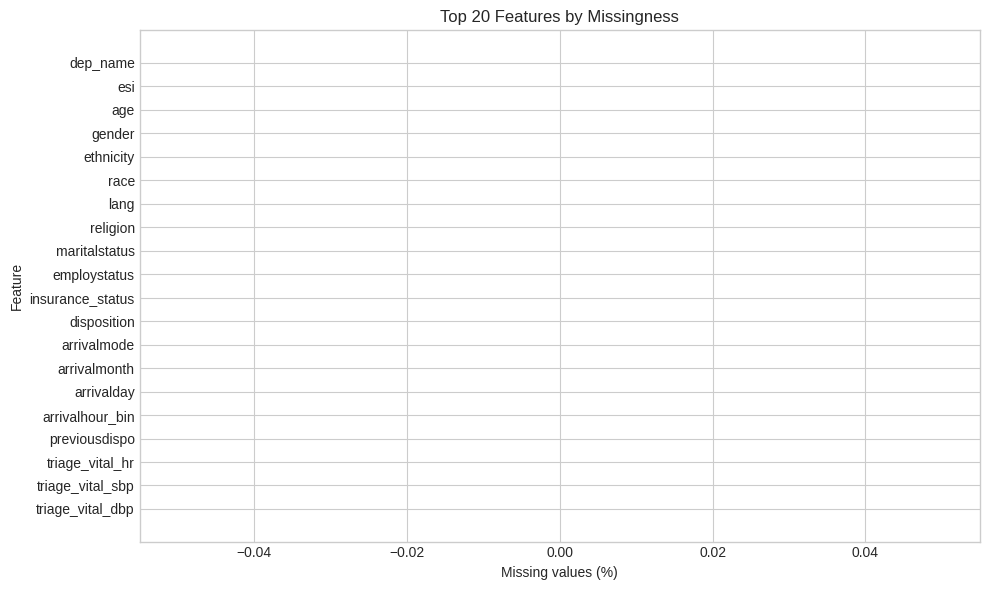

In [21]:
top_missing = missingness.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_missing["feature"], top_missing["missing_percent"])
plt.xlabel("Missing values (%)")
plt.ylabel("Feature")
plt.title("Top 20 Features by Missingness")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "SOliver_Week5_Missingness_BarChart.png", dpi=300)
plt.show()

**Interpretation:**  
The missingness plot suggests that the displayed core features have very low or no missingness. This is encouraging for feasibility because key variables such as demographics, ESI, arrival information and triage vitals appear to be consistently recorded in the dataset. However, a full missingness table is still needed because some lower-ranked or less visible variables may have missing values that are not obvious from this chart.

**Note:**  
The missingness chart appears visually blank because the displayed top features have 0% missingness. This is still an important data-quality finding, but the accompanying missingness table should be reviewed to confirm whether any other variables have missing values.

## 5. ESI Target Variable Exploration

This section explores the Emergency Severity Index, or ESI, which is the target variable for triage modelling. Lower ESI values represent higher acuity, while higher ESI values represent lower acuity.

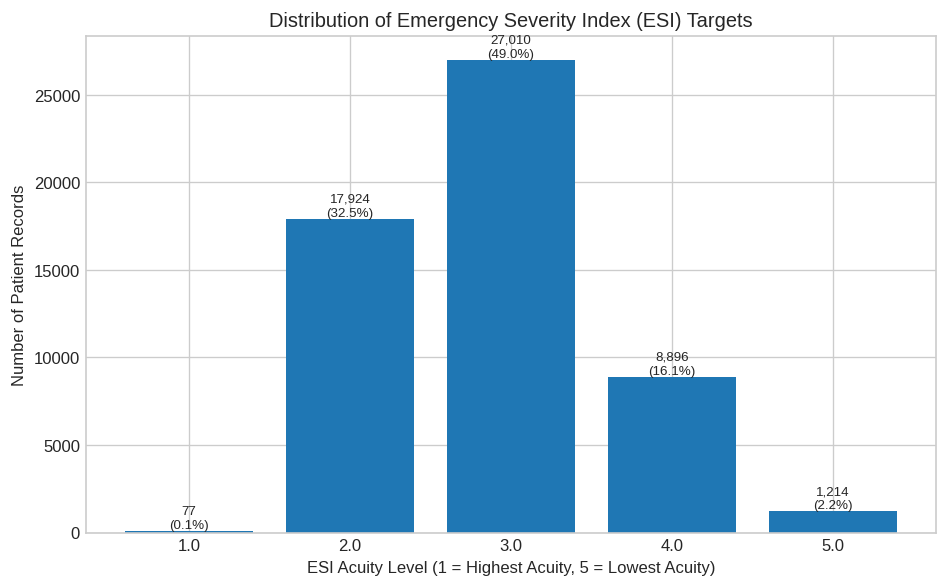

In [33]:
# ESI DISTRIBUTION PLOT
esi_counts = df["esi"].value_counts(dropna=False).sort_index()
esi_percent = (esi_counts / esi_counts.sum() * 100).round(1)

plt.figure(figsize=(8, 5))
bars = plt.bar(esi_counts.index.astype(str), esi_counts.values)

plt.xlabel("ESI Acuity Level (1 = Highest Acuity, 5 = Lowest Acuity)")
plt.ylabel("Number of Patient Records")
plt.title("Distribution of Emergency Severity Index (ESI) Targets")

for bar, pct in zip(bars, esi_percent):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}\n({pct}%)",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "SOliver_Week5_ESI_Distribution.png", dpi=300)
plt.show()

**Interpretation:**  
The ESI distribution shows that most records fall within ESI 2 and ESI 3, with ESI 3 being the most common category. There are far fewer ESI 1 and ESI 5 cases. This suggests class imbalance, which will be important for modelling because the algorithm may learn the majority categories more easily than rare high-acuity or low-acuity groups.

## 6. Demographic and Race/Ethnicity Exploration

This section explores demographic patterns in the dataset, including age and race. This is important because triage models should be assessed not only for overall performance, but also for whether the data support fair and reliable performance across patient groups.

<Figure size 1080x600 with 0 Axes>

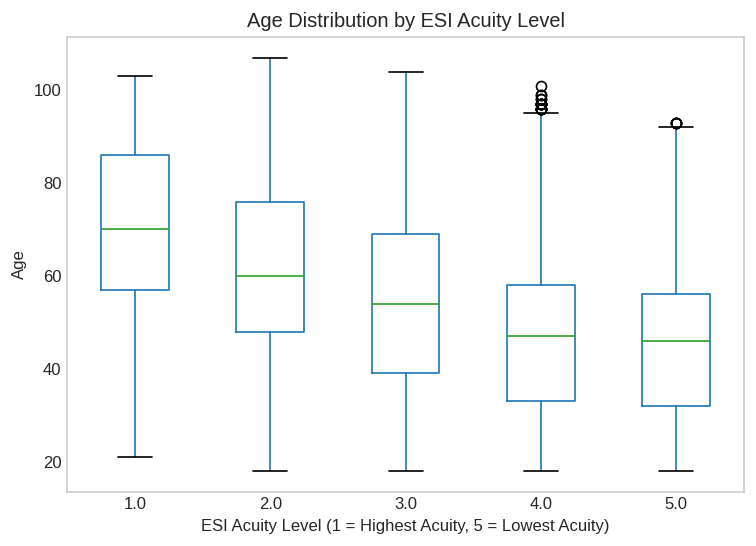

In [34]:
# AGE DISTRIBUTION BY ESI

age_esi = df[["age", "esi"]].dropna()

plt.figure(figsize=(9, 5))
age_esi.boxplot(column="age", by="esi", grid=False)

plt.title("Age Distribution by ESI Acuity Level")
plt.suptitle("")
plt.xlabel("ESI Acuity Level (1 = Highest Acuity, 5 = Lowest Acuity)")
plt.ylabel("Age")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "SOliver_Week5_Race_Distribution.png", dpi=300)
plt.show()

**Interpretation:**  
The age distribution shows that higher-acuity ESI groups tend to include older patients, especially ESI 1 and ESI 2. This supports age as a clinically relevant candidate feature because older patients may present with more complex illness, higher deterioration risk or less typical symptoms. Age should therefore be considered in the feature shortlist, while also being monitored carefully for fairness and over-reliance.

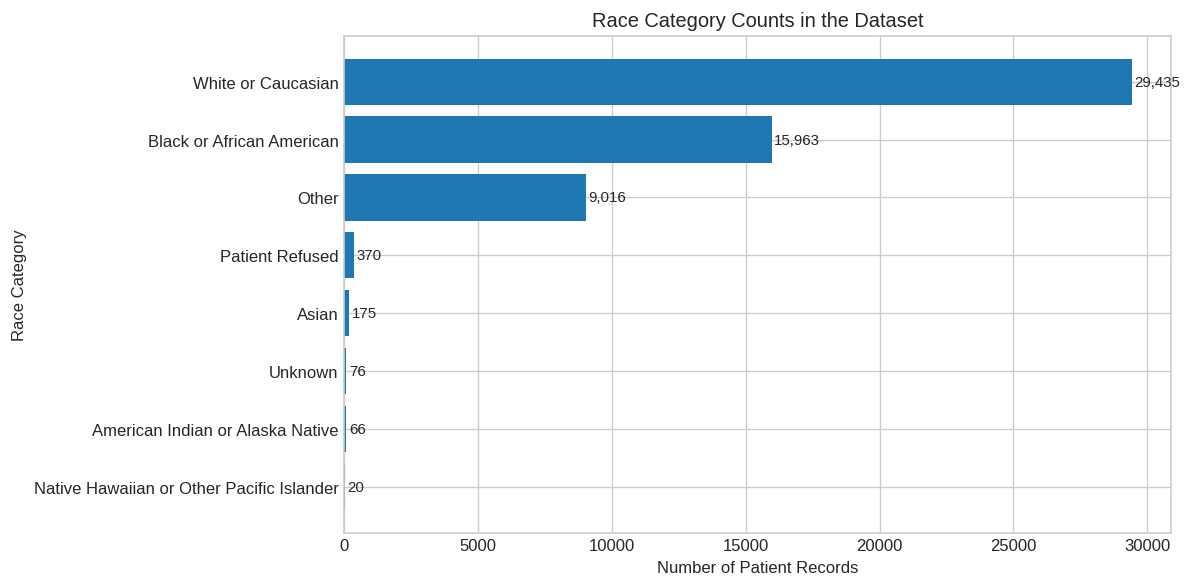

In [39]:
# RACE CATEGORY COUNTS PLOT

top_race = race_summary.head(10)

plt.figure(figsize=(10, 5))
bars = plt.barh(top_race["race"].astype(str), top_race["record_count"])

plt.xlabel("Number of Patient Records")
plt.ylabel("Race Category")
plt.title("Race Category Counts in the Dataset")
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 100,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "SOliver_Week5_Race_Category_Counts.png")
plt.show()

**Interpretation:**  
The race category count plot shows how many records are available for each racial group in the dataset. This is important for equity analysis because percentage-based comparisons can be misleading when a category has a small sample size. Groups with fewer records may show unstable patterns, so subgroup performance should be interpreted cautiously during model development.

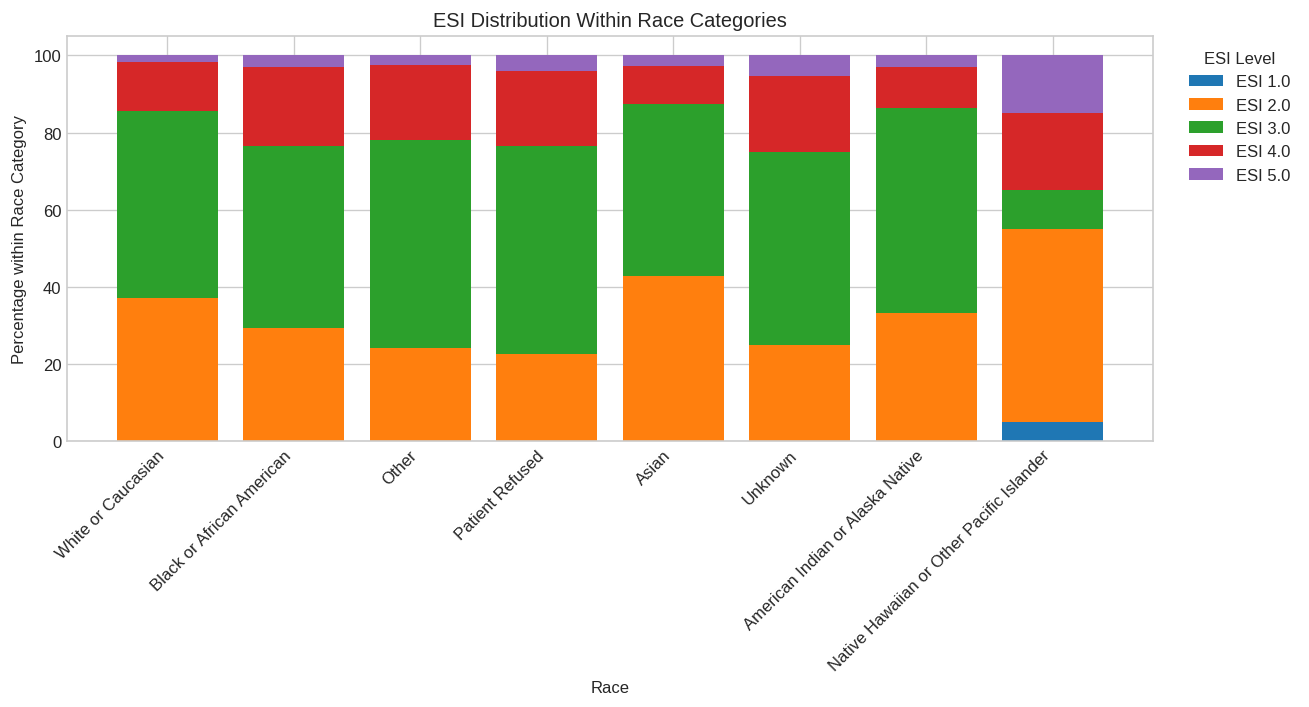

In [37]:
# ESI DISTRUBUTION BY RACE

race_esi = (
    pd.crosstab(df["race"], df["esi"], normalize="index") * 100
)

race_counts = df["race"].value_counts()
race_esi = race_esi.loc[race_counts.index]

plt.figure(figsize=(11, 6))

bottom = np.zeros(len(race_esi))

for col in sorted(race_esi.columns):
    plt.bar(
        race_esi.index.astype(str),
        race_esi[col],
        bottom=bottom,
        label=f"ESI {col}"
    )
    bottom += race_esi[col].values

plt.ylabel("Percentage within Race Category")
plt.xlabel("Race")
plt.title("ESI Distribution Within Race Categories")
plt.xticks(rotation=45, ha="right")
plt.legend(title="ESI Level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "SOliver_Week5_ESI_by_Race_Percentage.png")
plt.show()

In [38]:
race_summary = df["race"].value_counts(dropna=False).reset_index()
race_summary.columns = ["race", "record_count"]
race_summary["percent"] = (race_summary["record_count"] / len(df) * 100).round(1)

race_summary

,race,record_count,percent
0,White or Caucasian,29435,53.4
1,Black or African American,15963,29.0
2,Other,9016,16.4
3,Patient Refused,370,0.7
4,Asian,175,0.3
5,Unknown,76,0.1
6,American Indian or Alaska Native,66,0.1
7,Native Hawaiian or Other Pacific Islander,20,0.0


**Interpretation:**  
This plot compares the proportion of ESI levels within each race category. It is useful for identifying possible differences in triage distribution across groups, but it should not be interpreted as proof of bias by itself. Differences may reflect patient mix, access patterns, hospital presentation patterns or documentation practices. Further analysis would be needed before making any fairness claims.

## 7. Vital Signs and ESI Relationships

This section explores the relationship between triage vital signs and ESI. Vital signs are clinically important because they provide objective indicators of patient instability, but triage acuity is usually based on the full clinical picture rather than one measurement alone.

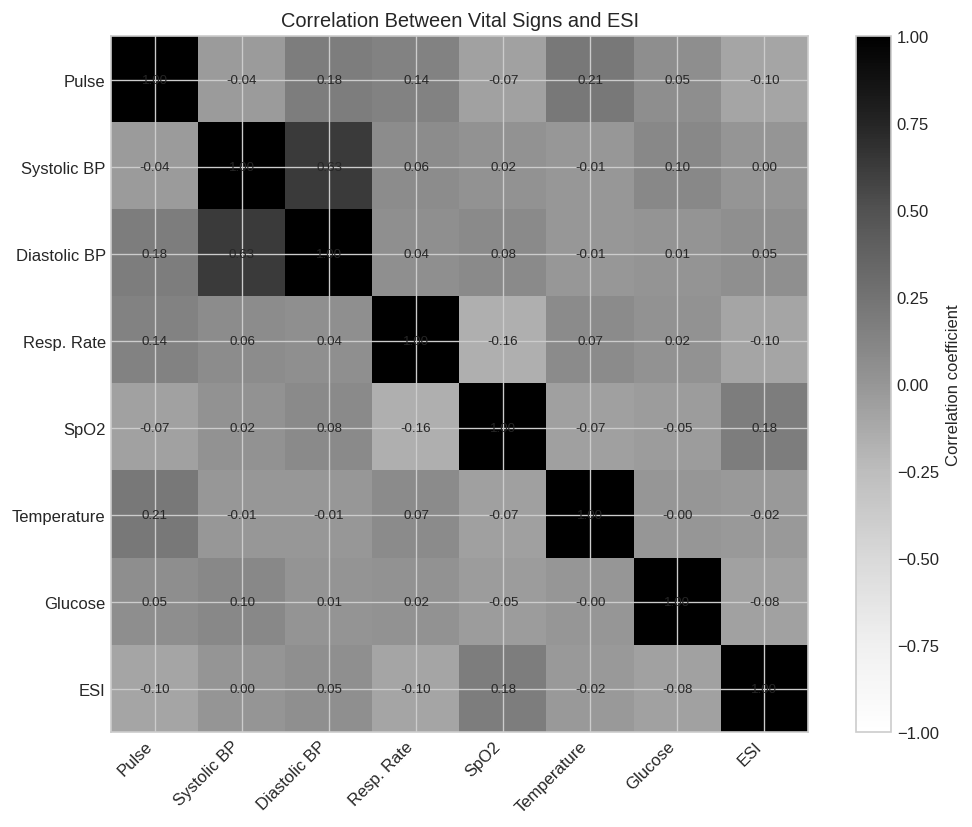

In [35]:
# CORRELATION HEATMAP

vital_map = {
    "triage_vital_hr": "Pulse",
    "triage_vital_sbp": "Systolic BP",
    "triage_vital_dbp": "Diastolic BP",
    "triage_vital_rr": "Resp. Rate",
    "triage_vital_o2": "SpO2",
    "triage_vital_temp": "Temperature",
    "triage_glucose": "Glucose",
    "esi": "ESI"
}

vital_cols = [col for col in vital_map.keys() if col in df.columns]

corr_df = df[vital_cols].rename(columns=vital_map).corr(numeric_only=True)

plt.figure(figsize=(9, 7))
im = plt.imshow(corr_df, vmin=-1, vmax=1)

plt.colorbar(im, label="Correlation coefficient")
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_df.index)), corr_df.index)

for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        value = corr_df.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.title("Correlation Between Vital Signs and ESI")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "SOliver_Week5_Vital_Signs_ESI_Correlation_Clean.png")
plt.show()

**Interpretation:**  
The correlation heatmap shows that individual vital signs have relatively weak linear correlations with ESI. This does not mean the variables are unimportant. In triage, risk is usually based on the combined clinical picture rather than one measurement alone. The weak correlations suggest that a useful model may need to combine vital signs, age, chief complaints, arrival mode and other context rather than relying on a single vital sign.

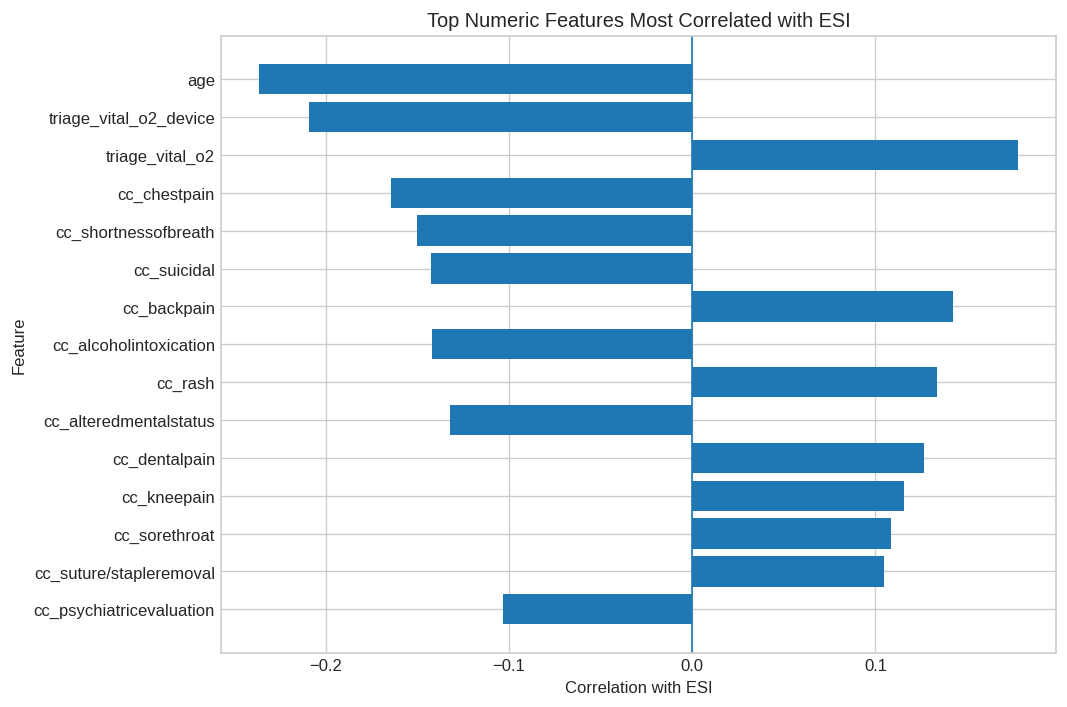

,esi
age,-0.236582
triage_vital_o2_device,-0.208956
triage_vital_o2,0.177859
cc_chestpain,-0.164328
cc_shortnessofbreath,-0.150285
cc_suicidal,-0.142603
cc_backpain,0.142140
cc_alcoholintoxication,-0.142127
cc_rash,0.133698
cc_alteredmentalstatus,-0.131958


In [36]:
# CORRELATION WITH ESI PLOT

numeric_cols = df.select_dtypes(include=["number"]).columns

corr_with_esi = (
    df[numeric_cols]
    .corr(numeric_only=True)["esi"]
    .drop("esi")
    .dropna()
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 6))
plt.barh(corr_with_esi.index, corr_with_esi.values)
plt.axvline(0, linewidth=1)

plt.xlabel("Correlation with ESI")
plt.ylabel("Feature")
plt.title("Top Numeric Features Most Correlated with ESI")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "SOliver_Week5_Top_Correlations_With_ESI.png")
plt.show()

corr_with_esi

**Interpretation:**  
This plot identifies numeric variables with the strongest simple correlation with ESI. Age, oxygen-related variables and several chief complaint flags appear among the more associated features. These findings help guide the initial feature shortlist, but they should not be treated as final feature importance because simple correlation only captures one type of relationship and may miss more complex clinical patterns.

## 8. Chief Complaint Exploration

This section explores chief complaint flags by body system. Chief complaints are clinically important because they describe why the patient presented to the emergency department and provide context for interpreting vital signs and acuity.

In [ ]:
groups = {
    "Trauma/Injury/MSK": [
        col for col in cc_flags
        if any(term in col for term in ["pain", "injury", "fall", "fracture", "laceration", "trauma"])
    ],
    "Respiratory": [
        col for col in cc_flags
        if any(term in col for term in ["shortnessofbreath", "cough", "asthma", "respiratory"])
    ],
    "Cardiovascular": [
        col for col in cc_flags
        if any(term in col for term in ["chestpain", "palpitations", "syncope"])
    ],
    "Gastrointestinal": [
        col for col in cc_flags
        if any(term in col for term in ["abdominal", "vomiting", "diarrhea", "nausea", "constipation"])
    ],
    "Neurological": [
        col for col in cc_flags
        if any(term in col for term in ["headache", "seizure", "dizziness", "alteredmentalstatus", "weakness"])
    ],
    "Psych/Behavioral/Substance": [
        col for col in cc_flags
        if any(term in col for term in ["suicidal", "psychiatric", "depression", "alcohol", "drug"])
    ],
    "ENT/Eye/Dental": [
        col for col in cc_flags
        if any(term in col for term in ["ear", "eye", "throat", "dental", "sorethroat"])
    ],
    "Skin/Soft-tissue": [
        col for col in cc_flags
        if any(term in col for term in ["rash", "abscess", "cellulitis", "wound"])
    ],
    "Genitourinary/Renal": [
        col for col in cc_flags
        if any(term in col for term in ["urinary", "flank", "renal", "vaginal", "testicular"])
    ],
    "Endocrine/Metabolic/Heme": [
        col for col in cc_flags
        if any(term in col for term in ["glucose", "diabetes", "sickle", "anemia"])
    ],
}

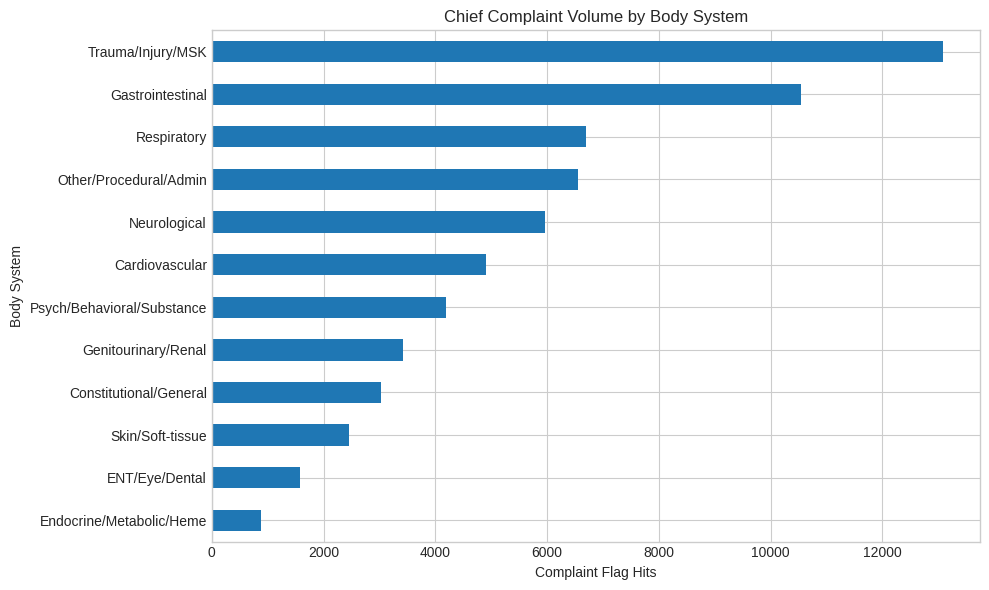

In [24]:
# CHIEF COMPLAINT VOLUME BY BODY SYSTEM

system_totals = {name: int(df[flags].sum().sum()) for name, flags in groups.items()}

system_totals_series = pd.Series(system_totals).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
system_totals_series.plot(kind="barh")
plt.xlabel("Complaint Flag Hits")
plt.ylabel("Body System")
plt.title("Chief Complaint Volume by Body System")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "SOliver_Week5_Complaint_Body_System_Distribution.png", dpi=300)
plt.show()

**Interpretation:**  
The chief complaint body-system plot shows that trauma/injury/musculoskeletal, gastrointestinal and respiratory complaints are among the most common presentations in the dataset. This supports the value of chief complaint flags for triage modelling because they capture the clinical reason for presentation. However, complaint categories should be interpreted alongside vital signs and patient context because the same complaint can represent different levels of urgency.